<a href="https://colab.research.google.com/github/Sreeja0522/Word-Vectors-in-NLP/blob/main/Semantic_Search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Human Language & Meaning

Keyword overlap ≠ semantic similarity

In [1]:
documents = [
    "How to train a neural network",
    "Introduction to deep learning",
    "Best recipes for homemade pizza",
    "Guide to machine learning algorithms",
    "Tips for teaching AI models",
    "How to care for pet dogs"
]

query = "How can I learn deep learning?"

print("Query:")
print(query)

print("\nDocuments:")
for i, doc in enumerate(documents):
    print(f"{i}: {doc}")

Query:
How can I learn deep learning?

Documents:
0: How to train a neural network
1: Introduction to deep learning
2: Best recipes for homemade pizza
3: Guide to machine learning algorithms
4: Tips for teaching AI models
5: How to care for pet dogs


In [2]:
#Naive Keyword Matching
#A simple baseline that counts overlapping words.

import re

def tokenize(text):
    return set(re.findall(r'\w+', text.lower()))

query_words = tokenize(query)

scores = []

for doc in documents:
    doc_words = tokenize(doc)
    overlap = len(query_words.intersection(doc_words))
    scores.append(overlap)

for score, doc in sorted(zip(scores, documents), reverse=True):
    print(f"Score={score} | {doc}")

Score=2 | Introduction to deep learning
Score=1 | How to train a neural network
Score=1 | How to care for pet dogs
Score=1 | Guide to machine learning algorithms
Score=0 | Tips for teaching AI models
Score=0 | Best recipes for homemade pizza


Naive methods don't consider semantic similarities.

In [4]:
#TF-IDF Similarity

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

documents = [
    "How to train a neural network",
    "Introduction to deep learning",
    "Best recipes for homemade pizza",
    "Guide to machine learning algorithms",
    "Tips for teaching AI models",
    "How to care for pet dogs"
]

query = "How can I learn deep learning?"

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(documents + [query])

doc_vectors = X[:-1]
query_vector = X[-1]

similarities = cosine_similarity(query_vector, doc_vectors)[0]

for doc, score in sorted(zip(documents, similarities),
                         key=lambda x: x[1],
                         reverse=True):
    print(f"{score:.4f}  |  {doc}")

0.3868  |  Introduction to deep learning
0.1329  |  How to train a neural network
0.1329  |  Guide to machine learning algorithms
0.1250  |  How to care for pet dogs
0.0000  |  Best recipes for homemade pizza
0.0000  |  Tips for teaching AI models


In [5]:
import pandas as pd

results = pd.DataFrame({
    "Document": documents,
    "Similarity": similarities
})

results.sort_values("Similarity", ascending=False)

,Document,Similarity
1,Introduction to deep learning,0.386774
0,How to train a neural network,0.132893
3,Guide to machine learning algorithms,0.132893
5,How to care for pet dogs,0.125034
2,Best recipes for homemade pizza,0.000000
4,Tips for teaching AI models,0.000000


The score is cosine similarity:

cos(θ)=∥A∥∥B∥/A⋅B
	​

Values mean:

1.0 → identical direction

0.0 → unrelated

-1.0 → opposite direction (rare here)

Even though "study" and "learn" are close in meaning, TF-IDF doesn't know that.

So the similarity scores may be lower than you'd expect.

This is exactly the problem Word2Vec solves:


In [6]:
#Word2Vec

!pip -q install gensim

from gensim.models import Word2Vec

sentences = [
    ["deep", "learning", "uses", "neural", "networks"],
    ["machine", "learning", "uses", "data"],
    ["artificial", "intelligence", "includes", "machine", "learning"],
    ["neural", "networks", "are", "used", "for", "deep", "learning"],
    ["dogs", "are", "pets"],
    ["cats", "are", "pets"],
]

model = Word2Vec(
    sentences,
    vector_size=50,
    window=3,
    min_count=1,
    workers=1,
    sg=1,
    epochs=500
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 41.9 MB/s eta 0:00:00


In [11]:
words = [
    "deep",
    "learning",
    "machine",
    "neural",
    "networks",
    "dogs",
    "cats"
]

import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

vectors = [model.wv[word] for word in words]

sim_matrix = cosine_similarity(vectors)

df = pd.DataFrame(
    sim_matrix,
    index=words,
    columns=words
)

df.round(3)

,deep,learning,machine,neural,networks,dogs,cats
deep,1.000,0.430,0.280,0.352,0.418,0.092,0.251
learning,0.430,1.000,0.333,0.407,0.381,0.202,0.102
machine,0.280,0.333,1.000,0.135,0.127,-0.012,0.067
neural,0.352,0.407,0.135,1.000,0.442,0.278,0.044
networks,0.418,0.381,0.127,0.442,1.000,0.076,0.206
dogs,0.092,0.202,-0.012,0.278,0.076,1.000,-0.185
cats,0.251,0.102,0.067,0.044,0.206,-0.185,1.000


In [10]:
for word in words:
    print("\n", word)
    print(model.wv.most_similar(word, topn=3))


 deep
[('learning', 0.4304121136665344), ('networks', 0.41808944940567017), ('includes', 0.38176125288009644)]

 learning
[('artificial', 0.5178582668304443), ('are', 0.49608057737350464), ('used', 0.49164053797721863)]

 machine
[('includes', 0.44338473677635193), ('learning', 0.3330604135990143), ('deep', 0.2795499563217163)]

 neural
[('intelligence', 0.5165978670120239), ('used', 0.46385708451271057), ('networks', 0.44228994846343994)]

 networks
[('are', 0.48820728063583374), ('intelligence', 0.44893738627433777), ('neural', 0.44228991866111755)]

 dogs
[('neural', 0.27842527627944946), ('artificial', 0.208133265376091), ('intelligence', 0.2078493982553482)]

 cats
[('for', 0.2938115894794464), ('deep', 0.25105565786361694), ('pets', 0.21676209568977356)]


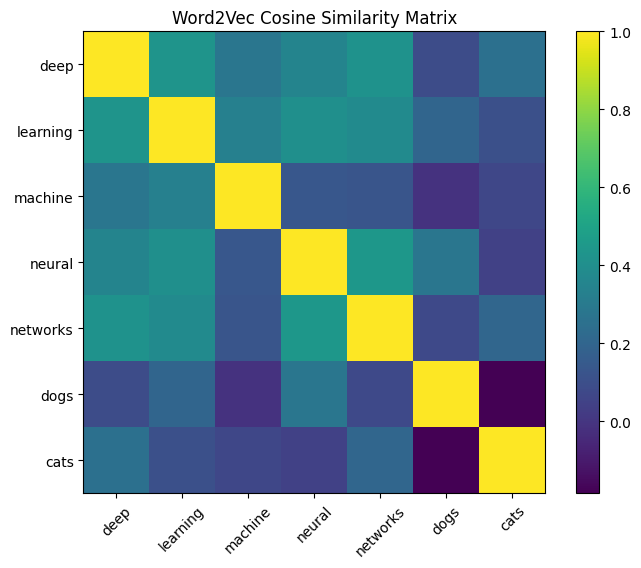

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(sim_matrix)
plt.colorbar()

plt.xticks(range(len(words)), words, rotation=45)
plt.yticks(range(len(words)), words)

plt.title("Word2Vec Cosine Similarity Matrix")
plt.show()

Word2Vec learned that "deep", "learning", "neural", and "networks" are semantically related because they appear in similar contexts, so their vectors have higher cosine similarity. The weaker and sometimes unexpected similarities involving "dogs" and "cats" are due to the extremely small training corpus, which doesn't provide enough context to learn robust relationships.

In [12]:
import numpy as np

# ============================================================
# STEP 1: INITIALIZE WORD EMBEDDINGS
# ============================================================

# Center word: deep
v_deep = np.array([0.2, -0.1])

# Context embeddings
u_learning = np.array([0.3, 0.1])
u_dogs = np.array([-0.2, 0.4])

print("Initial Embeddings")
print("v_deep     =", v_deep)
print("u_learning =", u_learning)
print("u_dogs     =", u_dogs)


# ============================================================
# STEP 2: TRAINING LOOP
# ============================================================

lr = 0.1
steps = 20

print("\n" + "="*60)
print("TRAINING")
print("="*60)

for step in range(steps):

    # ========================================================
    # STEP 3: COMPUTE SCORES (DOT PRODUCTS)
    # ========================================================

    score_learning = np.dot(u_learning, v_deep)
    score_dogs = np.dot(u_dogs, v_deep)

    scores = np.array([score_learning, score_dogs])

    # ========================================================
    # STEP 4: SOFTMAX PROBABILITIES
    # ========================================================

    exp_scores = np.exp(scores)
    probs = exp_scores / exp_scores.sum()

    p_learning = probs[0]
    p_dogs = probs[1]

    # ========================================================
    # STEP 5: OBJECTIVE FUNCTION
    # Correct context word = learning
    # ========================================================

    loss = -np.log(p_learning)

    # ========================================================
    # STEP 6: PRINT TRAINING STATUS
    # ========================================================

    print(
        f"Step {step:02d} | "
        f"P(learning|deep)={p_learning:.4f} | "
        f"P(dogs|deep)={p_dogs:.4f} | "
        f"Loss={loss:.4f}"
    )

    # ========================================================
    # STEP 7: COMPUTE GRADIENTS
    # ========================================================

    target = np.array([1, 0])

    grad_scores = probs - target

    grad_v = (
        grad_scores[0] * u_learning +
        grad_scores[1] * u_dogs
    )

    grad_u_learning = grad_scores[0] * v_deep
    grad_u_dogs = grad_scores[1] * v_deep

    # ========================================================
    # STEP 8: SGD UPDATE
    # ========================================================

    v_deep -= lr * grad_v
    u_learning -= lr * grad_u_learning
    u_dogs -= lr * grad_u_dogs


# ============================================================
# STEP 9: FINAL EMBEDDINGS
# ============================================================

print("\n" + "="*60)
print("FINAL EMBEDDINGS")
print("="*60)

print("v_deep     =", np.round(v_deep, 3))
print("u_learning =", np.round(u_learning, 3))
print("u_dogs     =", np.round(u_dogs, 3))


# ============================================================
# STEP 10: FINAL GEOMETRY
# ============================================================

final_score_learning = np.dot(u_learning, v_deep)
final_score_dogs = np.dot(u_dogs, v_deep)

print("\nFinal Dot Products")
print(f"deep · learning = {final_score_learning:.4f}")
print(f"deep · dogs     = {final_score_dogs:.4f}")


# ============================================================
# STEP 11: COSINE SIMILARITY
# ============================================================

def cosine(a, b):
    return np.dot(a, b) / (
        np.linalg.norm(a) * np.linalg.norm(b)
    )

print("\nCosine Similarities")
print(
    "deep ↔ learning =",
    round(cosine(v_deep, u_learning), 4)
)

print(
    "deep ↔ dogs     =",
    round(cosine(v_deep, u_dogs), 4)
)

Initial Embeddings
v_deep     = [ 0.2 -0.1]
u_learning = [0.3 0.1]
u_dogs     = [-0.2  0.4]

TRAINING
Step 00 | P(learning|deep)=0.5325 | P(dogs|deep)=0.4675 | Loss=0.6303
Step 01 | P(learning|deep)=0.5377 | P(dogs|deep)=0.4623 | Loss=0.6204
Step 02 | P(learning|deep)=0.5435 | P(dogs|deep)=0.4565 | Loss=0.6097
Step 03 | P(learning|deep)=0.5499 | P(dogs|deep)=0.4501 | Loss=0.5980
Step 04 | P(learning|deep)=0.5569 | P(dogs|deep)=0.4431 | Loss=0.5853
Step 05 | P(learning|deep)=0.5647 | P(dogs|deep)=0.4353 | Loss=0.5715
Step 06 | P(learning|deep)=0.5732 | P(dogs|deep)=0.4268 | Loss=0.5566
Step 07 | P(learning|deep)=0.5824 | P(dogs|deep)=0.4176 | Loss=0.5405
Step 08 | P(learning|deep)=0.5925 | P(dogs|deep)=0.4075 | Loss=0.5233
Step 09 | P(learning|deep)=0.6035 | P(dogs|deep)=0.3965 | Loss=0.5051
Step 10 | P(learning|deep)=0.6152 | P(dogs|deep)=0.3848 | Loss=0.4858
Step 11 | P(learning|deep)=0.6277 | P(dogs|deep)=0.3723 | Loss=0.4656
Step 12 | P(learning|deep)=0.6410 | P(dogs|deep)=0.3590 | 